In [1]:
%pip install pandas matplotlib seaborn

/Users/viegas/Projects/ufv/mestrado/causality-for-data-scientists-course/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# O Paradoxo de Simpson: Exemplo da Covid-19

Bem-vindo! Neste curso vamos mergulhar em um fenômeno capaz de fazer os números mentirem e transformar estatísticos em mágicos (ou em bobos). Ele se chama **Paradoxo de Simpson**.

Imagine o seguinte cenário: você está analisando dados de uma nova vacina. Confere os números gerais e parece que... os vacinados estão indo pior do que os não vacinados?

Calma lá... Você pode ter acabado de esbarrar no Paradoxo de Simpson. 
É um cenário em que uma tendência que aparece em diferentes grupos de dados desaparece (ou até se inverte!) quando esses grupos são combinados.

Vamos ver isso na prática com dados reais da Covid-19.

In [3]:
df = pd.read_csv('../datasets/1_simpsons_paradox_covid/dataset.csv')
df.sample(15, random_state=442)

,age_group,vaccine_status,outcome
134171,under 50,unvaccinated,survived
105277,under 50,unvaccinated,survived
4843,under 50,vaccinated,survived
195749,under 50,unvaccinated,survived
87286,under 50,vaccinated,survived
267625,50 +,unvaccinated,survived
116657,under 50,unvaccinated,survived
134136,under 50,unvaccinated,survived
245674,50 +,vaccinated,survived
88415,under 50,vaccinated,survived


> Este é um conjunto de dados sobre casos da variante Delta da Covid-19 no Reino Unido. Foi disponibilizado ao OpenIntro por Matthew T. Brenneman, da Embry-Riddle Aeronautical University.
>
> Observação: alguns totais da fonte original são diferentes porque havia casos sem idade associada.

## Vacinas são... ruins?

Vamos começar com a análise mais direta possível. Vamos agrupar todo mundo pelo status vacinal e ver qual porcentagem de pessoas em cada grupo, infelizmente, veio a óbito.

In [4]:
total_death_rate = df.groupby('vaccine_status')['outcome'].apply(lambda x: (x == 'death').sum() / len(x) * 100).reset_index(name='death_rate')

total_death_rate

,vaccine_status,death_rate
0,unvaccinated,0.167492
1,vaccinated,0.410711


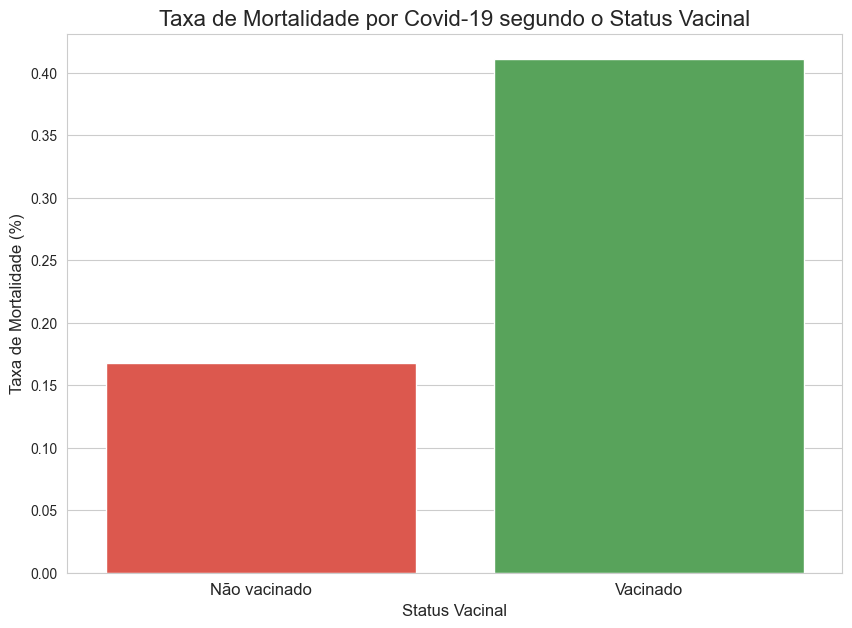

In [5]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 7))
palette = {"vaccinated": "#4CAF50", "unvaccinated": "#F44336"}

sns.barplot(data=total_death_rate, x='vaccine_status', y='death_rate', palette=palette, hue='vaccine_status', legend=False)

plt.title('Taxa de Mortalidade por Covid-19 segundo o Status Vacinal', fontsize=16)
plt.ylabel('Taxa de Mortalidade (%)', fontsize=12)
plt.xlabel('Status Vacinal', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Não vacinado', 'Vacinado'], fontsize=12)

plt.show()

### Uai, como assim?

Algo de errado não está certo. De acordo com nossa análise inicial, a taxa de mortalidade é **maior** no grupo vacinado.

Se parássemos por aqui, poderíamos postar isso nas redes sociais e causar no twitter. Esse é exatamente o tipo de fenômeno estatístico que alimenta a desinformação. Parece sugerir que a vacina não só está falhando, como, na verdade, é *mais* perigosa.

Mas, como cientistas de dados, sabemos que não devemos tirar conclusões precipitadas. Precisamos perguntar: **será que tem mais coisa rolando aqui?** Existe algum fator oculto, uma *variável de confusão* (confounding variable), bagunçando nossos resultados?

*(Alerta de spoiler: sim. Sim, existe.)*

## Plot twist

Em qualquer análise relacionada à saúde, qual é um dos fatores mais importantes a considerar? **Idade!**

Sabe-se que a Covid-19 é muito mais perigosa para pessoas mais velhas. Ao mesmo tempo, quem foi priorizado na vacinação? Os mais velhos!

Será que essa é a nossa variável de confusão? Vamos dividir os dados por `age_group` (faixa etária) e refazer as contas.

In [6]:
age_grouped_death_rate = df.groupby(['age_group', 'vaccine_status'])['outcome'].apply(lambda x: (x == 'death').sum() / len(x) * 100).reset_index(name='death_rate')

age_grouped_death_rate

,age_group,vaccine_status,death_rate
0,50 +,unvaccinated,5.959302
1,50 +,vaccinated,1.684550
2,under 50,unvaccinated,0.032518
3,under 50,vaccinated,0.023383


### Um Olhar Mais de Perto: Dividindo por Faixa Etária

O gráfico anterior é um pouco enganoso porque a escala do eixo y é dominada pelo grupo '50 +', dificultando ver a diferença no grupo 'under 50'. Vamos criar gráficos separados para cada faixa etária e ter uma visão mais clara.

/var/folders/3f/n4nyf4kn0cdcy8bv2ym0wsl00000gn/T/ipykernel_86345/2060740176.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Não vacinado', 'Vacinado'], fontsize=12)
/var/folders/3f/n4nyf4kn0cdcy8bv2ym0wsl00000gn/T/ipykernel_86345/2060740176.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Não vacinado', 'Vacinado'], fontsize=12)


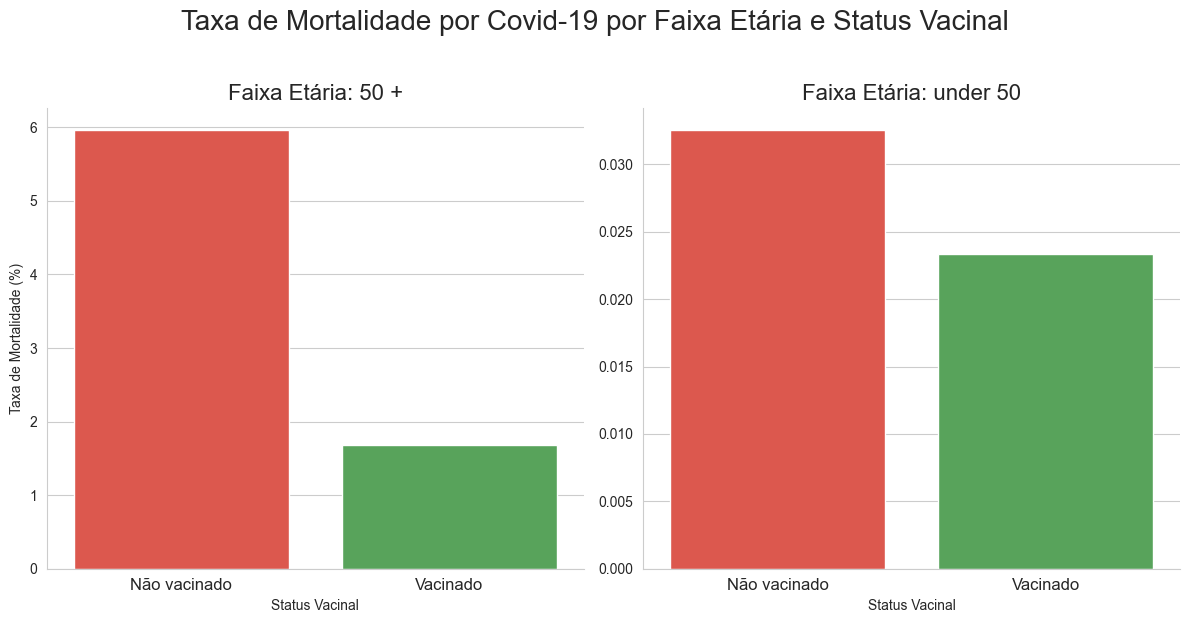

In [7]:
g = sns.FacetGrid(age_grouped_death_rate, col="age_group", height=6, aspect=1, sharey=False)
palette = {"vaccinated": "#4CAF50", "unvaccinated": "#F44336"}
g.map_dataframe(sns.barplot, x="vaccine_status", y="death_rate", hue="vaccine_status", palette=palette, legend=False)

g.set_axis_labels("Status Vacinal", "Taxa de Mortalidade (%)")
g.set_titles(col_template="Faixa Etária: {col_name}", size=16)

for ax in g.axes.flat:
    ax.set_xticklabels(['Não vacinado', 'Vacinado'], fontsize=12)

g.fig.suptitle('Taxa de Mortalidade por Covid-19 por Faixa Etária e Status Vacinal', y=1.03, fontsize=20)
plt.tight_layout()
plt.show()

## O Paradoxo

E aí está! A "mágica" é revelada:
- No grupo **'under 50'**, a taxa de mortalidade é menor entre os vacinados.
- No grupo **'50 +'**, a taxa de mortalidade *também* é menor entre os vacinados.

Ou seja, dentro de cada faixa etária, a vacina está claramente associada a uma taxa de mortalidade menor. O paradoxo é que, ao combinarmos esses grupos, a tendência se inverte.

**Por quê?** Porque o grupo '50 +' tem, naturalmente, uma taxa de mortalidade mais alta *e* uma taxa de vacinação muito maior. Esse grupo grande, de alto risco e altamente vacinado distorce os números gerais, fazendo a vacina parecer menos eficaz do que realmente é. Esse é um caso clássico de uma variável de confusão (a idade) bagunçando nossa interpretação.

Como a fonte dos dados descreve:

> Este conjunto de dados é um ótimo exemplo do Paradoxo de Simpson. Ao agregar os resultados sem considerar a faixa etária, a taxa de mortalidade dos vacinados aparece maior — mas esse grupo tem uma população de risco muito mais alta. Ao olharmos para populações com riscos mais comparáveis (separadas por faixa etária), vemos que o grupo vacinado tende a ter risco menor em cada faixa e que muitos dos pacientes de maior risco haviam sido vacinados.

_(traduzido)_

## Conclusão

O Paradoxo de Simpson é um lembrete poderoso de que correlação não é causalidade, e que dados agregados podem enganar perigosamente.

É por isso que modelos de IA/ML que dependem puramente de correlação podem gerar resultados que não se sustentam no mundo real, ou que não generalizam bem o suficiente. Porém, não é simples detectar esses detalhes e informar os modelos de IA/ML sobre esses cenários — e é exatamente por isso que a área de causalidade está recebendo tanto interesse!